#  Sprint: Análise de Dados e Boas Práticas  
## MVP: Análise Exploratória da Situação-Problema de Evasão Estudantil

###  Situação-Problema

A evasão estudantil é um problema relevante para instituições de ensino, impactando diretamente indicadores acadêmicos, planejamento institucional e desempenho dos alunos.

Neste MVP, o objetivo é analisar uma base de dados relacionada a estudantes, buscando compreender padrões associados à evasão.

###  Objetivo do MVP

Este MVP tem como objetivo:

- Realizar análise exploratória dos dados (EDA)
- Identificar padrões relevantes relacionados à evasão
- Avaliar a qualidade dos dados
- Preparar a base para futuras etapas de modelagem

##  Configuração do Ambiente

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

##  Ingestão de Dados

In [10]:
def carregar_dados(url: str) -> pd.DataFrame:
    print("Carregando dados...")
    df = pd.read_csv(url, sep=';')
    if df.shape[1] == 1:
        df = pd.read_csv(url, sep=',')
    print("Shape:", df.shape)
    return df

URL = "https://raw.githubusercontent.com/caesarw0/ml-dataset/main/students_dropout_prediction/data.csv"
df_cru = carregar_dados(URL)

Carregando dados...
Shape: (4424, 37)


##  Análise Inicial dos Dados

In [11]:
print("Dimensões:", df_cru.shape)

display(df_cru.head())
display(df_cru.dtypes)
display(df_cru.isnull().sum())
display(df_cru.describe().T)
display(df_cru.mode().head(1).T)

Dimensões: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


,0
Marital status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance\t,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


,0
Marital status,1
Application mode,1
Application order,1
Course,9500
Daytime/evening attendance\t,1
Previous qualification,1
Previous qualification (grade),133.1
Nacionality,1
Mother's qualification,1
Father's qualification,37


###  Análise

A base apresenta dados estruturados com variáveis numéricas e categóricas.

Não há presença significativa de valores nulos.

Observa-se a necessidade de padronização devido à diferença de escala entre variáveis.

##  Preparação dos Dados para Análise

In [12]:
def preparar_dados_eda(df):
    df_vis = df.copy()

    df_vis['Gender'] = df_vis['Gender'].map({1: 'Masculino', 0: 'Feminino'})
    df_vis['Tuition_Status'] = df_vis['Tuition fees up to date'].map({1: 'Em dia', 0: 'Atrasadas'})
    df_vis['Target_PT'] = df_vis['Target'].map({
        'Graduate': 'Formado',
        'Dropout': 'Evasão',
        'Enrolled': 'Matriculado'
    })

    df_vis['Faixa_Etaria'] = pd.cut(
        df_vis['Age at enrollment'],
        bins=[16, 20, 25, 30, 40, 100],
        labels=['17-20', '21-25', '26-30', '31-40', '40+']
    )

    return df_vis

df_eda = preparar_dados_eda(df_cru)

##  Distribuição da Variável Alvo

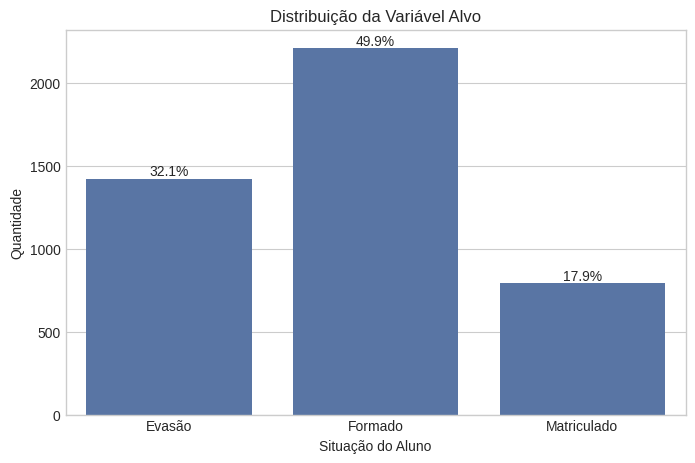

In [13]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_eda, x='Target_PT')

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{100*altura/len(df_eda):.1f}%',
                (p.get_x()+p.get_width()/2, altura),
                ha='center', va='bottom')

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Situação do Aluno')
plt.ylabel('Quantidade')
plt.show()

###  Análise

Observa-se que a maior parte dos alunos se forma, seguida por evasão.

A presença de alunos matriculados reforça a necessidade de ajuste da variável alvo.

##  Impacto da Inadimplência

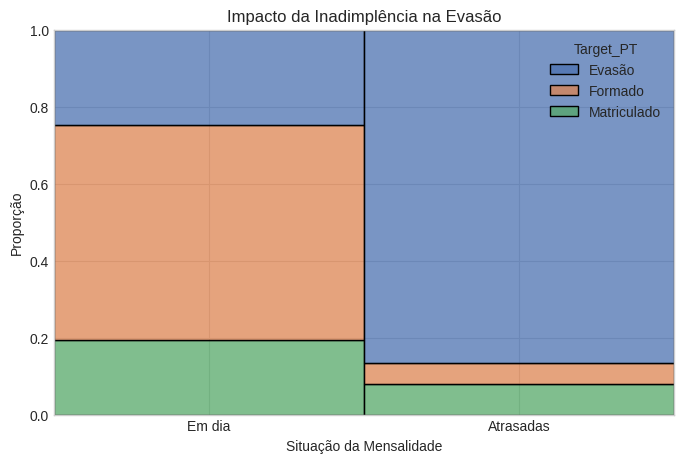

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_eda,
    x='Tuition_Status',
    hue='Target_PT',
    multiple='fill'
)

plt.title('Impacto da Inadimplência na Evasão')
plt.xlabel('Situação da Mensalidade')
plt.ylabel('Proporção')
plt.show()

###  Análise

Existe forte relação entre inadimplência e evasão.

Alunos com mensalidade atrasada apresentam maior taxa de evasão.

##  Pré-processamento dos Dados

In [16]:
def limpar_target(df):
    df = df[df['Target'] != 'Enrolled'].copy()
    df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0})
    return df

df_modelo = limpar_target(df_cru)

##  Transformação de Variáveis

In [17]:
def preparar_modelo(df):
    X = df.drop(columns=['Target'])
    y = df['Target'].astype(int)

    cols_cont = [c for c in X.columns if X[c].nunique() > 10]
    cols_cat = [c for c in X.columns if c not in cols_cont]

    X = pd.get_dummies(X, columns=cols_cat, drop_first=True)

    return X, y, cols_cont

X, y, cont = preparar_modelo(df_modelo)

##  Padronização dos Dados

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train[cont] = scaler.fit_transform(X_train[cont])
X_test[cont] = scaler.transform(X_test[cont])

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (2904, 76)
Teste: (726, 76)


###  Justificativa das Transformações

- Remoção de "Enrolled": não é desfecho final  
- Binarização: simplifica o problema  
- One-Hot Encoding: transforma categorias  
- Padronização: evita distorções  

##  Conclusão do MVP

Neste MVP, foi possível analisar os dados e aplicar as principais etapas de pré-processamento.

Os dados foram preparados para futuras etapas de modelagem, permitindo continuidade do projeto nas próximas Sprints.